### Generating human faces with Adversarial Networks
<!-- <img src="https://www.strangerdimensions.com/wp-content/uploads/2013/11/reception-robot.jpg" width=320> -->
This time we'll train a neural net to generate plausible human faces in all their subtlty: appearance, expression, accessories, etc. 'Cuz when us machines gonna take over the Earth, there won't be any more faces left. We want to preserve this data for future iterations. Yikes...

Based on https://github.com/Lasagne/Recipes/pull/94 .

In [4]:
#!L
from yfile import download_from_yadisk
import os

TARGET_DIR = '.'
FILENAME = "celeba.zip"

if not os.path.exists(os.path.join(TARGET_DIR, FILENAME)):
    # we are going to download 1.4 gb file, downloading will take some time
    download_from_yadisk(
        short_url='https://disk.yandex.ru/d/QErNx-MoC-2Y6Q',
        filename=FILENAME,
        target_dir=TARGET_DIR
    )

    # alternative way: 
    #from gfile import download_list
    #download_list(url=https://drive.google.com/file/d/1lwn2JMwWNGloGvyzKUOcewT8JqP1ICoW,
    #               filename=FILENAME, target_dir=TARGET_DIR)

filesize = os.path.getsize(os.path.join(TARGET_DIR, FILENAME))
GB = 2**30
assert filesize > 1 * GB, "{filesize} is too small, something wrong with downloading"

In [5]:
#!L:bash
!unzip celeba.zip

Archive:  celeba.zip
replace celeba/celeba/identity_CelebA.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

^C


In [ ]:
!pip3 install matplotlib
!pip3 install numpy
!pip3 install torch
!pip3 install torchvision

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 27.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 72.8 MB/s eta 0:00:00:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 94.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.9/113.9 KB 35.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.0/325.0 KB 72.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 74.0 MB/s eta 0:00:00ta 0:00:01


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 56.5 MB/s eta 0:00:0000:0100:01
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.8/899.8 MB 2.5 MB/s eta 0:00:0000:0100:02
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 3.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.3/39.3 MB 20.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 9.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 MB 6.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.3/170.3 MB 9.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 17.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 28.6 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━

In [6]:
#!L
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
plt.rcParams.update({'axes.titlesize': 'small'})

import torch, torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision.utils import make_grid

use_cuda = torch.cuda.is_available()

print("Torch version:", torch.__version__)
if use_cuda:
    print("Using GPU")
else:
    print("Not using GPU")

Torch version: 2.9.1+cu128
Using GPU


### Prepare Dataset

In [7]:
#!L
class CropCelebA64:
    
    def __call__(self, pic):
        new_pic = pic.crop((15, 40, 178 - 15, 218 - 30))
        return new_pic

    def __repr__(self):
        return self.__class__.__name__ + '()'

In all the rest, i will be using data preparation and architecture tricks from the classic DCGAN paper https://arxiv.org/pdf/1511.06434

Why this setup:
- classic, time proven, boring and stable
- modern setups are giving minor and incremental improvements
- i am using 16gb of VRAM

In [8]:
#!L

# Note that for simplicity we reduce the number of channels to 1
# But if you want to be hardcore feel free to comment .Grayscale :)

train_dataset = torchvision.datasets.CelebA(
    root='celeba',
    split='train',
    transform=torchvision.transforms.Compose([
        CropCelebA64(),
        torchvision.transforms.Resize(64),
        torchvision.transforms.RandomHorizontalFlip(),
        torchvision.transforms.ToTensor(),
        
        torchvision.transforms.Grayscale(),
        torchvision.transforms.Normalize(mean=[0.5], std=[0.5]),
    ]),
)

IMG_SHAPE = tuple(train_dataset[0][0].shape)

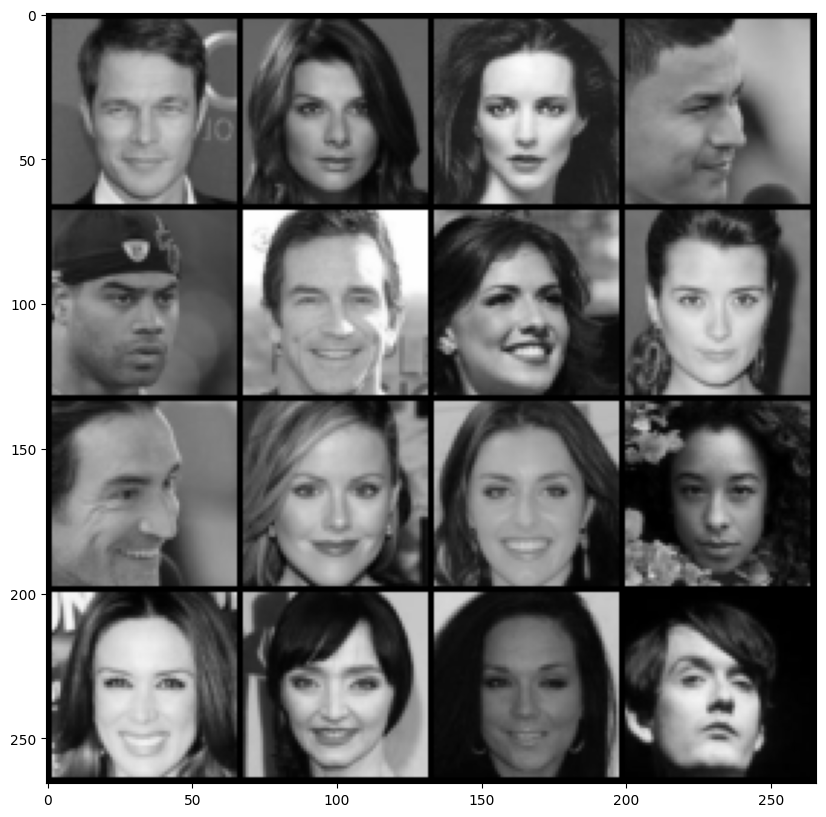

In [9]:
#!L
# print some images
samples = torch.stack([train_dataset[i][0] for i in range(32, 48)], dim=0)
# denorm
samples = (samples * 0.5 + 0.5).clamp(0,1)

plt.figure(figsize=(10, 10))
plt.imshow(make_grid(samples, nrow=4).permute(1, 2, 0))
plt.show()

# Generative adversarial nets 101

<img src="https://raw.githubusercontent.com/torch/torch.github.io/master/blog/_posts/images/model.png" width=320px height=240px>

Deep learning is simple, isn't it? 
* build some network that generates a face (small image)
* make up a __measure__ of __how good this face is__
* optimize with gradient descent :)


The only problem is: how can we engineers tell well-generated faces from bad? And i bet you we won't ask a designer for help. 

__If we can't tell good faces from bad, we delegate it to yet another neural network!__

That makes the two of them:
* __G__enerator - takes random noize for inspiration and tries to generate a face sample. 
  * Let's call him __G__(z), where z is a gaussian noize.
* __D__iscriminator - takes a face sample and tries to tell if it's great or fake. 
  * Predicts the probability of input image being a __real face__
  * Let's call him __D__(x), x being an image.
  * __D(x)__ is a predition for real image and __D(G(z))__ is prediction for the face made by generator.

Before we dive into training them, let's construct the two networks.

In [10]:
#!L
def sample_noise_batch(batch_size):
    noise = torch.randn(batch_size, CODE_SIZE)
    return noise.cuda() if use_cuda else noise.cpu()
    
class Reshape(nn.Module):
    def __init__(self, shape):
        nn.Module.__init__(self)
        self.shape = shape
    
    def forward(self,input):
        return input.view(self.shape)

In [11]:
#!L
CODE_SIZE = 100 # Size of z noise vector; feel free to change it

generator = nn.Sequential()

# DCGAN arch
generator.add_module('linear', nn.Linear(CODE_SIZE, 512*4*4))
generator.add_module('bn1', nn.BatchNorm1d(512*4*4))
generator.add_module('act1', nn.ReLU(True))
generator.add_module('reshape1', Reshape([-1, 512, 4, 4]))

generator.add_module('conv2', nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1, bias=False))
generator.add_module('bn2', nn.BatchNorm2d(256))
generator.add_module('act2', nn.ReLU(True))

generator.add_module('conv3', nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1, bias=False))
generator.add_module('bn3', nn.BatchNorm2d(128))
generator.add_module('act3', nn.ReLU(True))

generator.add_module('conv4', nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, bias=False))
generator.add_module('bn4', nn.BatchNorm2d(64))
generator.add_module('act4', nn.ReLU(True))

generator.add_module('conv_out', nn.ConvTranspose2d(64, 1, kernel_size=4, stride=2, padding=1, bias=False))
generator.add_module('out_act', nn.Tanh())


if use_cuda: generator.cuda()

In [12]:
#!L
generated_data = generator(sample_noise_batch(5))
assert tuple(generated_data.shape)[1:] == IMG_SHAPE, "generator must output an image of shape %s, but instead it produces %s"%(IMG_SHAPE, tuple(generated_data.shape)[1:])

### Discriminator
* Discriminator is your usual convolutional network with interlooping convolution and pooling layers
* The network does not include dropout/batchnorm to avoid learning complications.
* We also regularize the pre-output layer to prevent discriminator from being too certain.

In [13]:
#!L
def sample_data_batch(batch_size):
    idxs = np.random.choice(np.arange(len(train_dataset)), size=batch_size)
    batch = torch.stack([train_dataset[idx][0] for idx in idxs], dim=0)
    return batch.cuda() if use_cuda else batch.cpu()

# a special module that converts [batch, channel, w, h] to [batch, units]
class Flatten(nn.Module):
    def forward(self, input):
        return input.view(input.shape[0], -1)

In [14]:
#!L
from torch.nn.utils import spectral_norm as sn
discriminator = nn.Sequential()

# DCGAN
discriminator.add_module("conv1", sn(nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1)))
# discriminator.add_module("sn1", nn.utils.spectral_norm)
discriminator.add_module("act1", nn.LeakyReLU(0.2, inplace=True))

discriminator.add_module("conv2", sn(nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1)))
# discriminator.add_module("sn2", nn.utils.spectral_norm())
discriminator.add_module("act2", nn.LeakyReLU(0.2, inplace=True))

discriminator.add_module("conv3", sn(nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1)))
# discriminator.add_module("sn3", nn.utils.spectral_norm())
discriminator.add_module("act3", nn.LeakyReLU(0.2, inplace=True))

discriminator.add_module("conv4", sn(nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1)))
# discriminator.add_module("sn4", nn.utils.spectral_norm())
discriminator.add_module("act4", nn.LeakyReLU(0.2, inplace=True))

discriminator.add_module("conv_out", sn(nn.Conv2d(512, 1, kernel_size=4, stride=1, padding=0)))
# discriminator.add_module("sn4", nn.utils.spectral_norm())
discriminator.add_module("flatten", Flatten())

if use_cuda: discriminator.cuda()

In [15]:
#!L
discriminator(sample_data_batch(4))

tensor([[ 0.0095],
        [-0.0105],
        [ 0.0052],
        [ 0.0025]], device='cuda:0', grad_fn=<ViewBackward0>)

# Training

We train the two networks concurrently:
* Train __discriminator__ to better distinguish real data from __current__ generator
* Train __generator__ to make discriminator think generator is real
* Since discriminator is a differentiable neural network, we train both with gradient descent.

Training is done iteratively until discriminator is no longer able to find the difference (or until you run out of patience).


### Tricks:
* Regularize discriminator output weights to prevent explosion
* Train generator with __adam__ to speed up training. Discriminator trains with SGD to avoid problems with momentum.
* More: https://github.com/soumith/ganhacks


more tricks: DiffAufment https://github.com/mit-han-lab/data-efficient-gans

In [16]:
### DiffAugment ###
# MVP implementation

def _rand_translation(x, ratio=0.125):
    if ratio <= 0:
        return x
    b, c, h, w = x.shape
    shift_x = int(h * ratio + 0.5)
    shift_y = int(w * ratio + 0.5)
    if shift_x == 0 and shift_y == 0:
        return x
    tx = torch.randint(-shift_x, shift_x + 1, (b, 1, 1), device=x.device)
    ty = torch.randint(-shift_y, shift_y + 1, (b, 1, 1), device=x.device)
    x = torch.roll(x, shifts=(int(tx[0].item()), int(ty[0].item())), dims=(2, 3))
    return x

def _rand_cutout(x, ratio=0.5):
    if ratio <= 0:
        return x
    b, c, h, w = x.shape
    cutout_h = int(h * ratio + 0.5)
    cutout_w = int(w * ratio + 0.5)
    if cutout_h < 1 or cutout_w < 1:
        return x
    cx = torch.randint(0, h, (b,), device=x.device)
    cy = torch.randint(0, w, (b,), device=x.device)

    mask = torch.ones((b, 1, h, w), device=x.device, dtype=x.dtype)
    x0 = (cx - cutout_h // 2).clamp(0, h)
    x1 = (cx + cutout_h // 2).clamp(0, h)
    y0 = (cy - cutout_w // 2).clamp(0, w)
    y1 = (cy + cutout_w // 2).clamp(0, w)
    for i in range(b):
        mask[i, :, x0[i]:x1[i], y0[i]:y1[i]] = 0
    return x * mask


def DiffAugment(x, policy="translation,cutout"):
    if policy is None or policy.strip() == "":
        return x
    for p in [p.strip() for p in policy.split(",") if p.strip()]:
        if p == "translation":
            x = _rand_translation(x, ratio=0.125)
        elif p == "cutout":
            x = _rand_cutout(x, ratio=0.5)
        else:
            raise ValueError(f"Unknown DiffAugment policy: {p}")
    return x

In [17]:
#!L
def generator_loss(noise):
    """
    1. generate data given noise
    2. compute log P(real | gen noise)
    3. return generator loss (should be scalar)
    """
    generated_data = generator(noise)
    generated_data = DiffAugment(generated_data)
    
    disc_on_generated_data = discriminator(generated_data)
    
    logp_gen_is_real = F.logsigmoid(disc_on_generated_data)
    
    loss = -logp_gen_is_real.mean()
    
    return loss

In [18]:
#!L
loss = generator_loss(sample_noise_batch(32))

print(loss)

assert len(loss.shape) == 0, "Loss must be scalar"

tensor(0.6884, device='cuda:0', grad_fn=<NegBackward0>)


In [19]:
#!L
def discriminator_loss(real_data, generated_data):
    """
    1. compute discriminator's output on real & generated data
    2. compute log-probabilities of real data being real, generated data being fake
    3. return discriminator loss (scalar)
    """
    real_data_aug = DiffAugment(real_data)
    generated_data_aug = DiffAugment(generated_data)

    disc_on_real_data = discriminator(real_data_aug)
    disc_on_fake_data = discriminator(generated_data_aug)
    
    logp_real_is_real = F.logsigmoid(disc_on_real_data)
    logp_gen_is_fake = F.logsigmoid(-disc_on_fake_data)
    
    loss = -(logp_real_is_real + logp_gen_is_fake).mean()
    return loss

In [20]:
#!L
loss = discriminator_loss(sample_data_batch(32), 
                   generator(sample_noise_batch(32)))

print(loss)

assert len(loss.shape) == 0, "Loss must be scalar"

tensor(1.3733, device='cuda:0', grad_fn=<NegBackward0>)


### Auxilary functions
Here we define a few helper functions that draw current data distributions and sample training batches.

In [21]:
#!L
def sample_images(nrow, ncol, sharp=False):
    was_training = generator.training
    generator.eval()
    with torch.no_grad():
        images = generator(sample_noise_batch(batch_size=nrow*ncol))
        images = (images * 0.5 + 0.5).clamp(0, 1)
        images = images.data.cpu().numpy().transpose([0, 2, 3, 1])
    if was_training:
        generator.train()
    # if np.var(images)!=0:
    #     images = images.clip(0, 1)
    for i in range(nrow*ncol):
        plt.subplot(nrow,ncol,i+1)
        if sharp:
            plt.imshow(images[i], cmap="gray", interpolation="none")
        else:
            plt.imshow(images[i], cmap="gray")
    plt.show()

def sample_probas(batch_size):
    plt.title('Generated vs real data')
    D_real = torch.sigmoid(discriminator(sample_data_batch(batch_size)))
    generated_data_batch = generator(sample_noise_batch(batch_size))
    D_fake = torch.sigmoid(discriminator(generated_data_batch))
    
    plt.hist(D_real.data.cpu().numpy(),
             label='D(x)', alpha=0.5, range=[0,1])
    plt.hist(D_fake.data.cpu().numpy(),
             label='D(G(z))', alpha=0.5, range=[0,1])
    plt.legend(loc='best')
    plt.show()

### Training
Main loop.
We just train generator and discriminator in a loop and draw results once every N iterations.

In [ ]:
#!L
# optimizers
# hyperparams from DCGAN paper, from where we stole the arch
disc_opt = torch.optim.Adam(discriminator.parameters(), lr=4e-4, betas=(0.0, 0.9))
gen_opt = torch.optim.Adam(generator.parameters(), lr=2e-4, betas=(0.0, 0.9))

In [23]:
!pip3 install tqdm

Defaulting to user installation because normal site-packages is not writeable


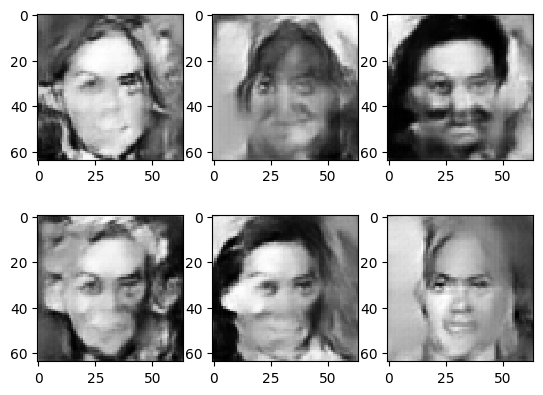

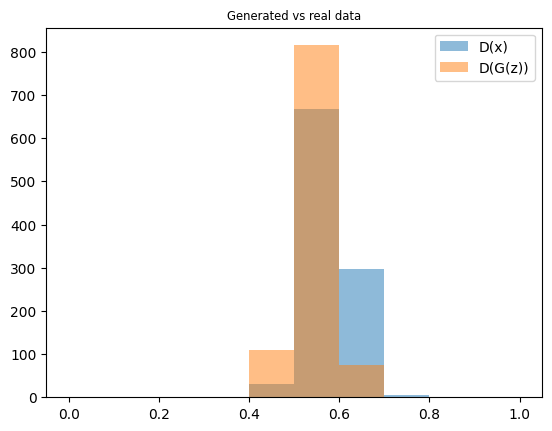

  0%|          | 0/1627 [00:01<?, ?it/s]


In [24]:
#!L
from IPython import display
from tqdm.auto import tqdm

batch_size = 100
loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)

generator.train()
discriminator.train()
max_iter = 15000
global_step = 0

for epoch in range(25):
    for iteration, (batch, _) in tqdm(enumerate(loader), total=len(loader)):

        # Train discriminator
        real_data = batch.cuda() if use_cuda else batch.cpu()
        fake_data = generator(sample_noise_batch(batch_size))
        d_loss = discriminator_loss(real_data, fake_data)
        disc_opt.zero_grad(set_to_none=True)
        d_loss.backward()
        disc_opt.step()

        # Train generator
        g_noise = sample_noise_batch(batch_size)
        g_loss = generator_loss(g_noise)
        gen_opt.zero_grad(set_to_none=True)
        g_loss.backward()
        gen_opt.step()

        global_step += 1

        if iteration % 100 == 0:
            print(epoch)
            display.clear_output(wait=True)
            sample_images(2,3,True)
            sample_probas(1000)
        
        if global_step >= max_iter:
            break

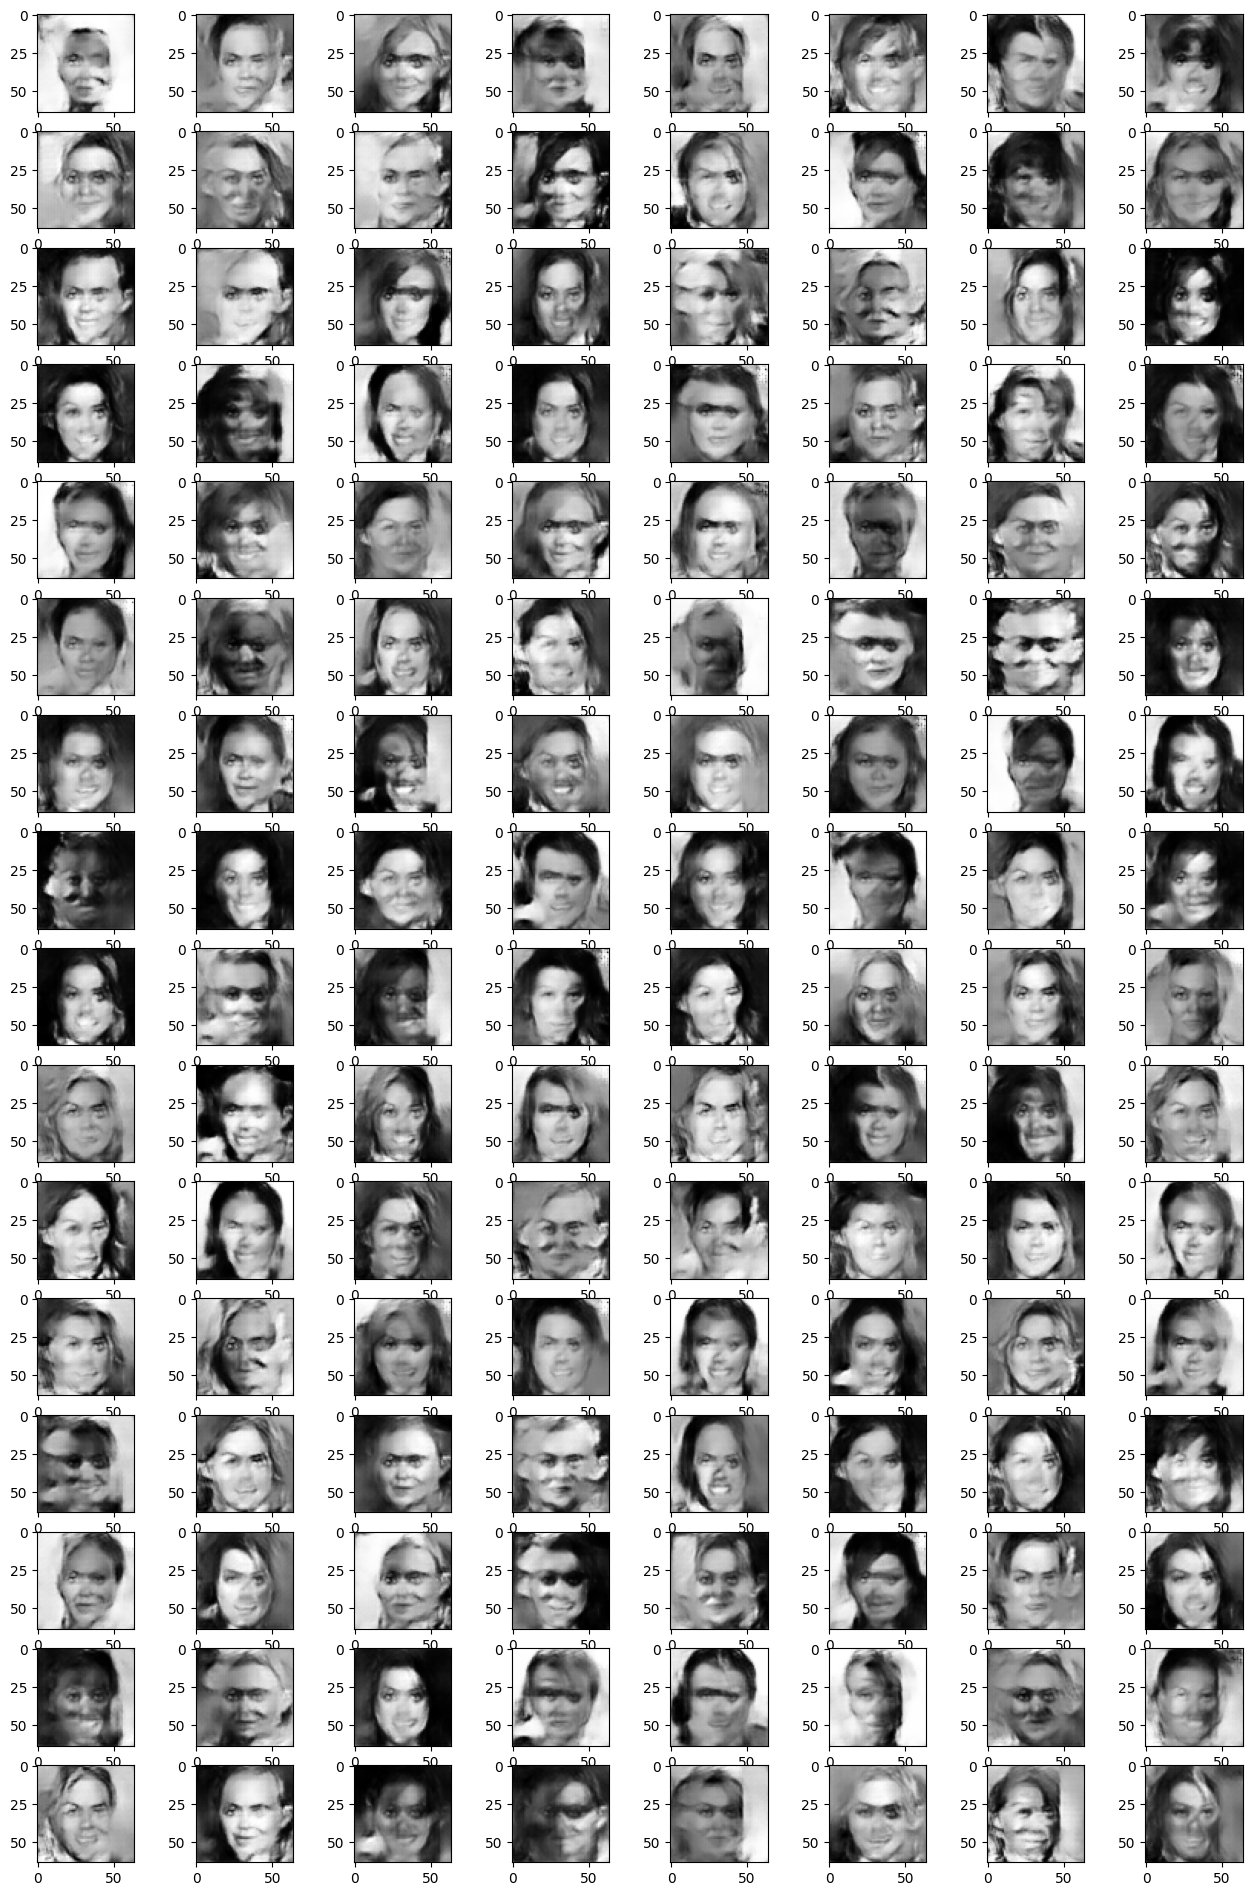

In [25]:
#!L
plt.figure(figsize=[16, 24])
sample_images(16, 8)

# Note: a no-nonsense neural network should be able to produce reasonably good images after 15k iterations
# By "reasonably good" we mean "resembling a car crash victim" or better

Well, reasonably good for a characters of a new Fallout part. Biggest remarks:
- most of the faces, look like a blend of a few other faces... frankesteins
- face contours are reasonably restored
- great inspiration for a horror movie or game